# Chapitre 9 — Réduction de dimension, clustering et introduction à la modélisation

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

## Objectifs

- Comprendre et interpréter une **Analyse en Composantes Principales (ACP)**.
- Segmenter des individus par **k-means** (et hiérarchique), choisir $k$, profiler les groupes.
- Ajuster et évaluer une **régression linéaire** et une **classification** avec une méthodologie rigoureuse
  (train/test, validation croisée, métriques adaptées).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
sns.set_theme(style="whitegrid", palette="colorblind")
clients = pd.read_csv(DATA / "clients_mobile_money.csv")
variables = ["nb_transactions_mois", "montant_moyen_fcfa", "part_montant_recu",
             "part_paiement_marchand", "anciennete_mois", "age"]
clients[variables].describe().round(2)

,nb_transactions_mois,montant_moyen_fcfa,part_montant_recu,part_paiement_marchand,anciennete_mois,age
count,2300.00,2300.00,2300.00,2300.00,2300.00,2300.00
mean,29.58,27268.70,0.42,0.27,24.41,36.43
std,32.23,38325.19,0.24,0.22,16.44,11.48
min,1.00,500.00,0.00,0.00,1.00,18.00
25%,6.00,4400.00,0.25,0.08,11.00,28.00
50%,11.00,15000.00,0.35,0.20,22.00,35.00
75%,39.00,30400.00,0.54,0.44,36.00,43.00
max,139.00,397700.00,1.00,0.93,84.00,79.00


## 1. Analyse en Composantes Principales (ACP)

### 1.1 Idée
Trouver de **nouveaux axes** (combinaisons linéaires des variables) qui capturent **le plus de variance possible**,
deux à deux **non corrélés**. Mathématiquement, sur les données **centrées-réduites** $Z$ ($n \times p$) :

$$\frac{1}{n-1} Z^\top Z = V \Lambda V^\top$$

- les colonnes de $V$ (vecteurs propres) sont les **directions** des composantes (*loadings*) ;
- les valeurs propres $\lambda_k$ sont les **variances** des composantes ; $\lambda_k / \sum_j \lambda_j$ = part de variance expliquée ;
- les **coordonnées** des individus sont $Z V$.

⚠️ **Standardiser** avant l'ACP quand les unités diffèrent (FCFA vs mois), sinon la variable de plus grande variance domine.

In [2]:
Xc = clients[variables].copy()
Xc["montant_moyen_fcfa"] = np.log10(Xc["montant_moyen_fcfa"])      # réduire l'asymétrie
Z = StandardScaler().fit_transform(Xc)

acp = PCA().fit(Z)
var_exp = pd.DataFrame({"valeur propre": acp.explained_variance_,
                        "% variance": acp.explained_variance_ratio_ * 100,
                        "% cumulé": acp.explained_variance_ratio_.cumsum() * 100},
                       index=[f"CP{i + 1}" for i in range(len(variables))])
var_exp.round(2)

,valeur propre,% variance,% cumulé
CP1,2.69,44.75,44.75
CP2,1.80,29.99,74.74
CP3,0.59,9.80,84.54
CP4,0.44,7.39,91.93
CP5,0.35,5.84,97.77
CP6,0.13,2.23,100.00


Vérifions que c'est bien la décomposition en éléments propres de la matrice de corrélation :

In [3]:
valeurs_propres = np.linalg.eigvalsh(np.corrcoef(Z, rowvar=False))[::-1]
print(np.round(valeurs_propres * len(Z) / (len(Z) - 1), 4))
print(np.round(acp.explained_variance_, 4))

[2.686  1.8002 0.5884 0.4438 0.3506 0.1337]
[2.686  1.8002 0.5884 0.4438 0.3506 0.1337]


### 1.2 Combien de composantes garder ?
- **Éboulis** (*scree plot*) : chercher le « coude » ;
- **Kaiser** : valeurs propres > 1 (sur données réduites) ;
- un **seuil cumulé** (ex. 80 %).

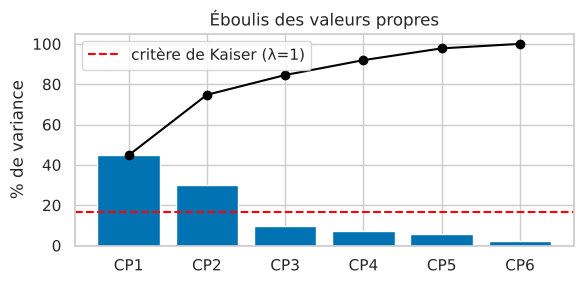

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(var_exp.index, var_exp["% variance"]); ax.plot(var_exp.index, var_exp["% cumulé"], "o-", color="black")
ax.axhline(100 / len(variables), ls="--", color="red", label="critère de Kaiser (λ=1)")
ax.set(ylabel="% de variance", title="Éboulis des valeurs propres"); ax.legend()
plt.tight_layout(); plt.show()

### 1.3 Interpréter : cercle des corrélations et projection des individus

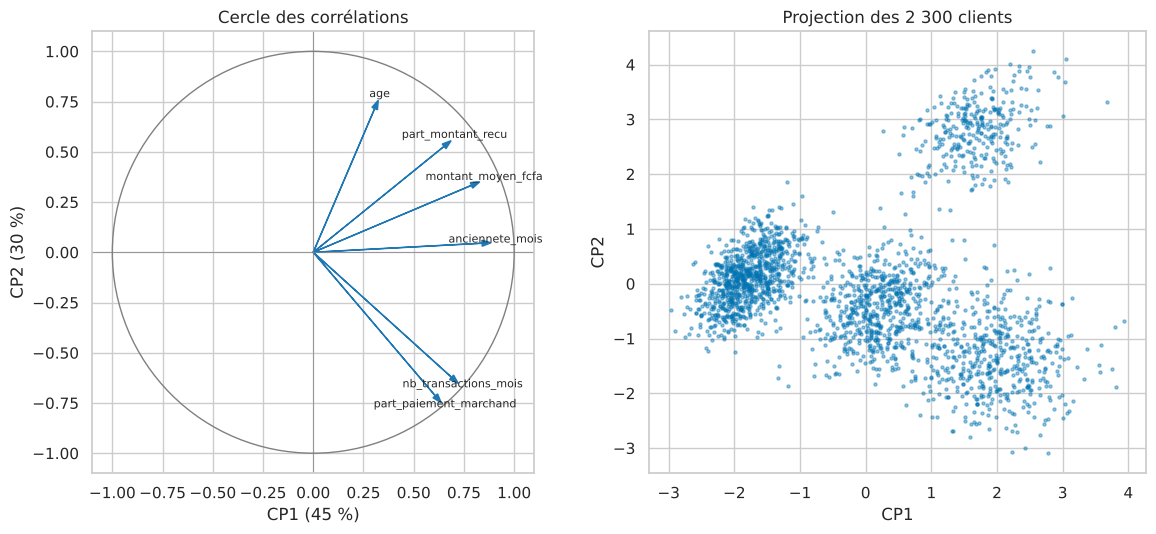

In [5]:
correlations = acp.components_.T * np.sqrt(acp.explained_variance_)   # corrélation variable–composante
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
ax = axes[0]
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="gray"))
for i, v in enumerate(variables):
    ax.arrow(0, 0, correlations[i, 0], correlations[i, 1], head_width=0.03, color="tab:blue")
    ax.text(correlations[i, 0] * 1.08, correlations[i, 1] * 1.08, v, fontsize=8, ha="center")
ax.set(xlim=(-1.1, 1.1), ylim=(-1.1, 1.1), aspect="equal",
       xlabel=f"CP1 ({var_exp.iloc[0, 1]:.0f} %)", ylabel=f"CP2 ({var_exp.iloc[1, 1]:.0f} %)", title="Cercle des corrélations")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)

coord = acp.transform(Z)
axes[1].scatter(coord[:, 0], coord[:, 1], s=5, alpha=0.4)
axes[1].set(xlabel="CP1", ylabel="CP2", title="Projection des 2 300 clients")
plt.tight_layout(); plt.show()

**Lecture** : deux variables proches du cercle et proches entre elles sont **corrélées positivement** ;
opposées → corrélées négativement ; à angle droit → peu corrélées. Une variable près du centre est mal représentée
dans ce plan. Le nuage des individus montre déjà des **groupes** : passons au clustering.

## 2. Clustering (classification non supervisée)

### 2.1 k-means
Minimise l'**inertie intra-classe** $\sum_{k}\sum_{i \in C_k} \|z_i - \mu_k\|^2$ par l'algorithme de Lloyd :
1. choisir $k$ centres initiaux (k-means++) ; 2. affecter chaque point au centre le plus proche ;
3. recalculer les centres ; 4. répéter jusqu'à stabilité.

### 2.2 Choisir k : coude et silhouette
Le **coefficient de silhouette** d'un point compare sa distance moyenne à son groupe ($a$) et au groupe voisin le plus proche ($b$) :
$s = (b - a)/\max(a, b) \in [-1, 1]$ ; proche de 1 = bien classé.

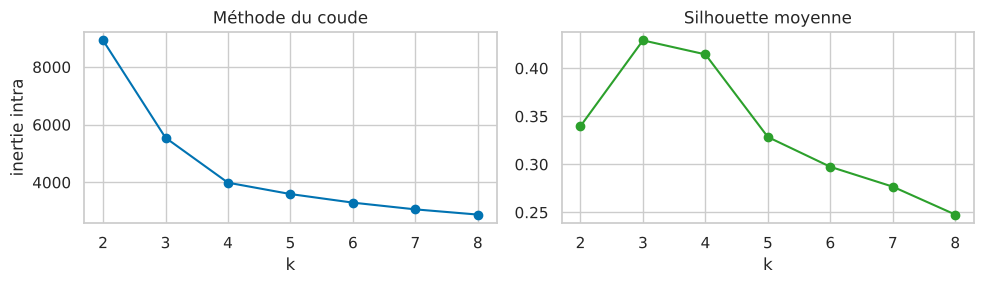

k retenu (silhouette max) : 3


In [6]:
ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(Z, km.labels_, sample_size=1500, random_state=0))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(ks, inerties, "o-"); axes[0].set(title="Méthode du coude", xlabel="k", ylabel="inertie intra")
axes[1].plot(ks, silhouettes, "o-", color="tab:green"); axes[1].set(title="Silhouette moyenne", xlabel="k")
plt.tight_layout(); plt.show()
k_opt = list(ks)[int(np.argmax(silhouettes))]
print("k retenu (silhouette max) :", k_opt)

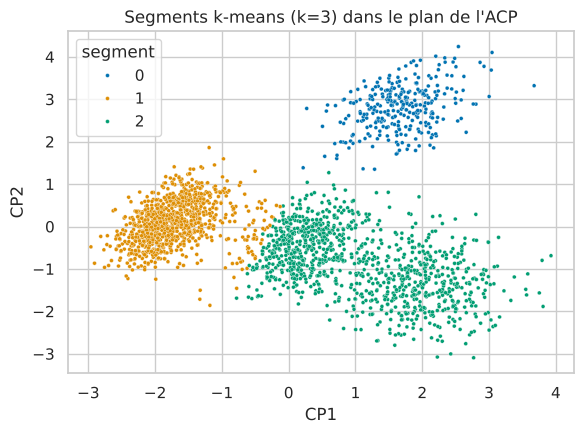

In [7]:
km = KMeans(n_clusters=k_opt, n_init=10, random_state=0).fit(Z)
clients["segment"] = km.labels_
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.scatterplot(x=coord[:, 0], y=coord[:, 1], hue=clients["segment"], palette="colorblind", s=8, ax=ax)
ax.set(xlabel="CP1", ylabel="CP2", title=f"Segments k-means (k={k_opt}) dans le plan de l'ACP")
plt.tight_layout(); plt.show()

### 2.3 Profiler et nommer les segments — l'étape qui donne du sens

In [8]:
profil = clients.groupby("segment")[variables].median()
profil["effectif"] = clients["segment"].value_counts().sort_index()
profil.round(2)

,nb_transactions_mois,montant_moyen_fcfa,part_montant_recu,part_paiement_marchand,anciennete_mois,age,effectif
segment,,,,,,,
0,8.0,96400.0,0.92,0.05,39.0,53.0,301
1,6.0,3800.0,0.29,0.11,10.0,34.0,958
2,42.0,21500.0,0.37,0.47,32.0,34.0,1041


Exemple de lecture : un segment avec beaucoup de transactions et une forte part de paiements marchands → **commerçants** ;
un segment avec de gros montants reçus et peu de transactions → **réception de transferts (diaspora)**, etc.

Comme les données sont simulées, on connaît les « vrais » segments : l'**indice de Rand ajusté** (ARI)
mesure l'accord (1 = parfait, 0 = hasard). *Sur des données réelles, cette vérité n'existe pas.*

In [9]:
print("ARI k-means :", round(adjusted_rand_score(clients["segment_reel"], clients["segment"]), 3))
print(pd.crosstab(clients["segment_reel"], clients["segment"]))

ARI k-means : 0.705
segment         0    1    2
segment_reel               
commercant      0    0  500
diaspora      300    0    0
petit_usage     0  900    0
salarie         1   58  541


🔎 **Leçon importante** : la silhouette a retenu $k=3$ alors que les données ont été simulées avec **4** profils —
commerçants et salariés sont fusionnés. Les critères automatiques sont des **aides à la décision**, pas des oracles :
on compare plusieurs $k$ et on garde la segmentation **la plus utile et interprétable** pour le métier. Essayons $k=4$ :

In [10]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Z)
print("ARI k-means (k=4) :", round(adjusted_rand_score(clients["segment_reel"], km4.labels_), 3))
print(pd.crosstab(clients["segment_reel"], km4.labels_))

ARI k-means (k=4) : 0.978
col_0           0    1    2    3
segment_reel                    
commercant     11    0  489    0
diaspora        0    0    0  300
petit_usage     4  896    0    0
salarie       596    3    1    0


### 2.4 Classification hiérarchique ascendante (CAH, critère de Ward)
Fusionne itérativement les deux groupes dont la fusion augmente le moins l'inertie intra ; le **dendrogramme**
aide à choisir le nombre de classes.

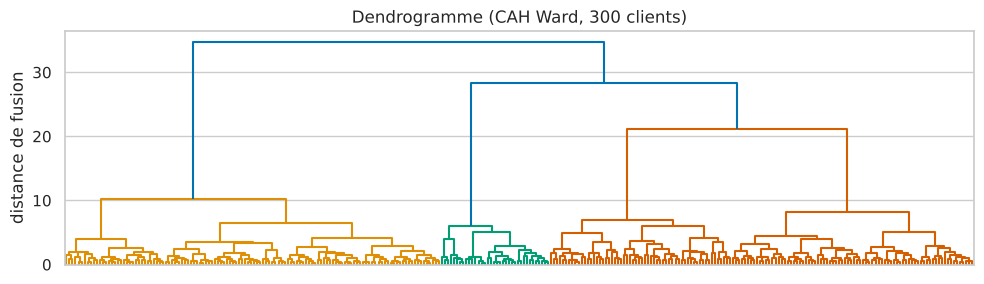

ARI CAH : 0.746


In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

echantillon = np.random.default_rng(0).choice(len(Z), 300, replace=False)
fig, ax = plt.subplots(figsize=(10, 3))
dendrogram(linkage(Z[echantillon], method="ward"), no_labels=True, ax=ax, color_threshold=25)
ax.set(title="Dendrogramme (CAH Ward, 300 clients)", ylabel="distance de fusion")
plt.tight_layout(); plt.show()
cah = AgglomerativeClustering(n_clusters=k_opt, linkage="ward").fit(Z)
print("ARI CAH :", round(adjusted_rand_score(clients["segment_reel"], cah.labels_), 3))

> Limites de k-means : suppose des groupes **convexes** de tailles comparables, sensible à l'échelle et aux extrêmes.
> Alternatives : **DBSCAN** (formes quelconques, détection de bruit), **mélanges gaussiens** (appartenance probabiliste).

## 3. Introduction à la modélisation supervisée

### 3.1 Le protocole

```text
données ─► séparation train / test (le test est mis sous clé)
             │
             ├─► train : choix du modèle et réglages par validation croisée (k plis)
             │
             └─► test : UNE évaluation finale, pour estimer la performance sur des données nouvelles
```

Comparer **toujours** à une **référence naïve** (*baseline*) : prédire la moyenne, la classe majoritaire…

### 3.2 Régression linéaire : expliquer la note d'examen

In [12]:
import statsmodels.formula.api as smf

etu = pd.read_csv(DATA / "resultats_etudiants.csv")
reg = smf.ols("note_examen ~ note_controle_continu + heures_etude_semaine + C(tutorat) + C(filiere)", data=etu).fit()
print(reg.summary().tables[1])
print(f"R² = {reg.rsquared:.3f} | R² ajusté = {reg.rsquared_adj:.3f}")

                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       4.3487      0.430     10.114      0.000       3.504       5.193
C(tutorat)[T.Oui]               1.0222      0.177      5.776      0.000       0.675       1.370
C(filiere)[T.Informatique]      0.0913      0.242      0.377      0.707      -0.385       0.567
C(filiere)[T.Mathématiques]    -0.6707      0.232     -2.888      0.004      -1.127      -0.215
C(filiere)[T.Économie]          0.7477      0.240      3.116      0.002       0.276       1.219
note_controle_continu           0.5321      0.031     16.931      0.000       0.470       0.594
heures_etude_semaine            0.1197      0.016      7.394      0.000       0.088       0.152
R² = 0.408 | R² ajusté = 0.402


**Interprétation** d'un coefficient : « toutes choses égales par ailleurs, une heure d'étude hebdomadaire de plus est
associée à +β points à l'examen ». Vérifier les **résidus** (linéarité, variance constante, normalité approximative) :

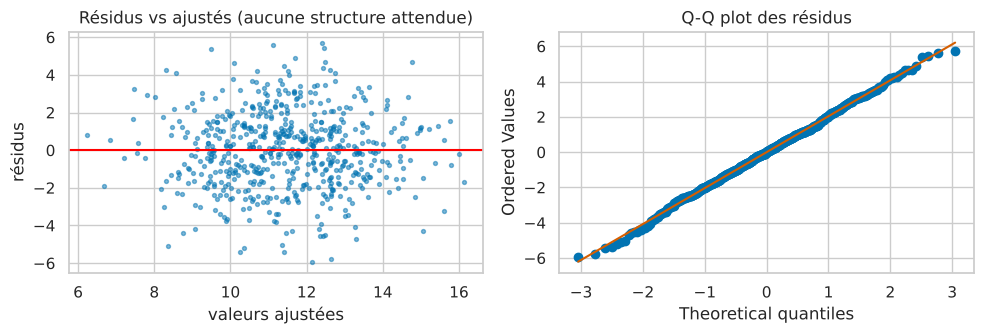

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(reg.fittedvalues, reg.resid, s=8, alpha=0.5); axes[0].axhline(0, color="red")
axes[0].set(xlabel="valeurs ajustées", ylabel="résidus", title="Résidus vs ajustés (aucune structure attendue)")
from scipy import stats
stats.probplot(reg.resid, plot=axes[1]); axes[1].set_title("Q-Q plot des résidus")
plt.tight_layout(); plt.show()

### 3.3 Classification : prédire l'admission, avec validation croisée et métriques adaptées

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder

X = etu[["heures_etude_semaine", "note_controle_continu", "tutorat", "filiere", "sexe"]]
y = (etu["admis"] == "Oui").astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

prep = ColumnTransformer([("num", StandardScaler(), ["heures_etude_semaine", "note_controle_continu"]),
                          ("cat", OneHotEncoder(drop="if_binary"), ["tutorat", "filiere", "sexe"])])
candidats = {
    "baseline (classe majoritaire)": DummyClassifier(strategy="most_frequent"),
    "régression logistique": LogisticRegression(max_iter=1000),
    "forêt aléatoire": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0),
}
cv = StratifiedKFold(5, shuffle=True, random_state=0)
resultats = {}
for nom, clf in candidats.items():
    r = cross_validate(make_pipeline(prep, clf), X_tr, y_tr, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
    resultats[nom] = {m: f"{r[f'test_{m}'].mean():.3f} ± {r[f'test_{m}'].std():.3f}" for m in ["accuracy", "f1", "roc_auc"]}
pd.DataFrame(resultats).T

,accuracy,f1,roc_auc
baseline (classe majoritaire),0.704 ± 0.005,0.827 ± 0.004,0.500 ± 0.000
régression logistique,0.764 ± 0.023,0.839 ± 0.019,0.817 ± 0.023
forêt aléatoire,0.747 ± 0.011,0.830 ± 0.008,0.808 ± 0.016


On retient le modèle le plus simple parmi les meilleurs, puis **une seule** évaluation sur le test :

              precision    recall  f1-score   support

   Non admis       0.66      0.42      0.51        45
       Admis       0.79      0.90      0.84       105

    accuracy                           0.76       150
   macro avg       0.72      0.66      0.68       150
weighted avg       0.75      0.76      0.74       150

AUC ROC test : 0.839


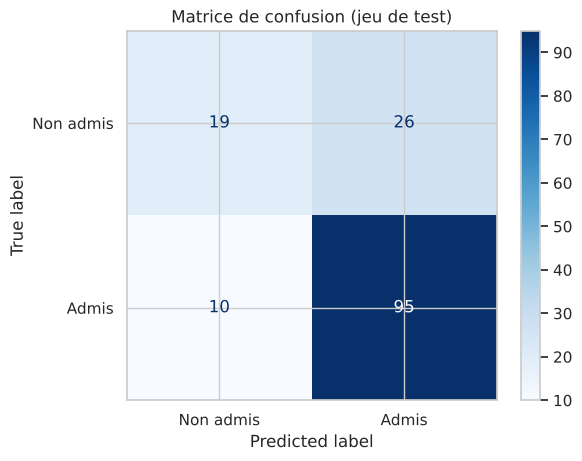

In [15]:
final = make_pipeline(prep, LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
proba = final.predict_proba(X_te)[:, 1]
print(classification_report(y_te, final.predict(X_te), target_names=["Non admis", "Admis"]))
print(f"AUC ROC test : {roc_auc_score(y_te, proba):.3f}")
ConfusionMatrixDisplay.from_estimator(final, X_te, y_te, display_labels=["Non admis", "Admis"], cmap="Blues")
plt.title("Matrice de confusion (jeu de test)"); plt.show()

| Métrique | Définition | Quand l'utiliser |
|---|---|---|
| Exactitude (*accuracy*) | % de bonnes prédictions | classes équilibrées |
| Précision | parmi les prédits positifs, % vrais positifs | coût élevé des faux positifs |
| Rappel (sensibilité) | parmi les vrais positifs, % détectés | coût élevé des faux négatifs (dépistage) |
| F1 | moyenne harmonique précision/rappel | classes déséquilibrées |
| AUC ROC | capacité à **classer** positifs avant négatifs | indépendant du seuil |
| RMSE / MAE / R² | erreurs de régression | régression |

## À retenir

- ACP : **standardiser**, choisir le nombre d'axes (éboulis, Kaiser, % cumulé), **interpréter** par le cercle des corrélations.
- Clustering : choisir $k$ (coude, silhouette), puis **profiler et nommer** les segments — c'est là qu'est la valeur métier.
- Modélisation : séparation train/test, **validation croisée**, **baseline**, métriques adaptées, test utilisé **une seule fois**.

**Références** : Jolliffe I. & Cadima J. (2016), « Principal component analysis: a review… », *Phil. Trans. R. Soc. A* 374 ;
Husson F., Lê S., Pagès J. (2016), *Analyse de données avec R*, PUR ; James G. et al. (2023),
*An Introduction to Statistical Learning with Applications in Python* (en ligne : <https://www.statlearning.com/>) ;
Rousseeuw P. (1987), « Silhouettes… », *J. Comput. Appl. Math.* 20.

🎓 **Fin du cours.** Mettez tout en pratique avec les **projets** du dossier `projets/`.